In [2]:
import pandas as pd

def prepare_schedule_data(filepath):
    # Read the dataset
    df = pd.read_csv(filepath)
    
    # Drop empty point columns since the games haven't been played yet
    df = df.drop(columns=['Pts', 'Pts.1'])
    
    # Rename unnamed columns for better readability
    df = df.rename(columns={
        'Unnamed: 2': 'Date',
        'Unnamed: 5': 'LocationIndicator' # All values are '@'
    })
    
    # Clean up the 'Time' column just in case there's trailing whitespace
    df['Time'] = df['Time'].str.strip()
    
    # Add an indicator for International Games
    # NFL games in Europe almost exclusively start at 9:30 AM Eastern Time
    df['Is_International'] = df['Time'] == '9:30 AM'
    
    return df

# Load the data
schedule_df = prepare_schedule_data('data/2026_schedule.csv')

# Let's verify the international games
international_games = schedule_df[schedule_df['Is_International']]
print(f"Found {len(international_games)} international games:")
print(international_games[['Week', 'VisTm', 'HomeTm', 'Time']])

Found 6 international games:
     Week                 VisTm                 HomeTm     Time
49      4    Indianapolis Colts  Washington Commanders  9:30 AM
65      5   Philadelphia Eagles   Jacksonville Jaguars  9:30 AM
80      6        Houston Texans   Jacksonville Jaguars  9:30 AM
94      7   Pittsburgh Steelers     New Orleans Saints  9:30 AM
122     9    Cincinnati Bengals        Atlanta Falcons  9:30 AM
137    10  New England Patriots          Detroit Lions  9:30 AM


In [3]:
schedule_df = pd.read_csv('data/2026_schedule.csv')

In [5]:
import pandas as pd

def calculate_schedule_advantages(df):

    
    # 3. Team to Timezone mapping (Offsets from UTC)
    tz_map = {
        'New England Patriots': -5, 'New York Jets': -5, 'Buffalo Bills': -5, 'Miami Dolphins': -5,
        'Baltimore Ravens': -5, 'Cincinnati Bengals': -5, 'Cleveland Browns': -5, 'Pittsburgh Steelers': -5,
        'Indianapolis Colts': -5, 'Jacksonville Jaguars': -5, 'New York Giants': -5, 'Philadelphia Eagles': -5,
        'Washington Commanders': -5, 'Detroit Lions': -5, 'Atlanta Falcons': -5, 'Carolina Panthers': -5,
        'Tampa Bay Buccaneers': -5,
        'Houston Texans': -6, 'Tennessee Titans': -6, 'Kansas City Chiefs': -6, 'Dallas Cowboys': -6,
        'Chicago Bears': -6, 'Green Bay Packers': -6, 'Minnesota Vikings': -6, 'New Orleans Saints': -6,
        'Denver Broncos': -7, 'Arizona Cardinals': -7,
        'Las Vegas Raiders': -8, 'Los Angeles Chargers': -8, 'Los Angeles Rams': -8, 'San Francisco 49ers': -8,
        'Seattle Seahawks': -8
    }
    
    # Map Timezones to the teams
    df['VisTm_TZ'] = df['VisTm'].map(tz_map)
    df['HomeTm_TZ'] = df['HomeTm'].map(tz_map)
    
    # Calculate Timezone Difference for the visiting team
    # Positive means traveling East (e.g., Pacific -8 to Eastern -5 -> -5 - (-8) = +3)
    df['Vis_Travel_East'] = df['HomeTm_TZ'] - df['VisTm_TZ']
    
    # 4. Determine Disadvantages
    def assign_disadvantages(row):
        # Even out international games
        if row['Is_International']:
            return 0, 0 
            
        vis_dis = 0
        home_dis = 0
        
        # Traveling east more than 1 timezone
        if row['Vis_Travel_East'] > 1:
            vis_dis = 1
            home_adv = 1 # Playing a team traveling east > 1 timezone
            
        return pd.Series([vis_dis, home_adv])

    df[['Vis_Disadvantage', 'Home_Advantage']] = df.apply(assign_disadvantages, axis=1)
    
    # 5. Summarize to find who has the biggest schedule advantage (Fewest disadvantages)
    vis_totals = df.groupby('VisTm')['Vis_Disadvantage'].sum()
    home_totals = df.groupby('HomeTm')['Home_Advantage'].sum()
    
    total_disadvantages = vis_totals.add(home_totals, fill_value=0).sort_values(ascending=False)
    
    return df, total_disadvantages

# Run the function
schedule_df, disadvantage_totals = calculate_schedule_advantages(schedule_df)

# Look at the teams with the highest and lowest disadvantages
print("--- Biggest Disadvantages ---")
print(disadvantage_totals.head(5))

print("\n--- Biggest Advantages (0 Disadvantages) ---")
print(disadvantage_totals.tail(5))

--- Biggest Disadvantages ---
VisTm
Las Vegas Raiders       5
Los Angeles Chargers    5
San Francisco 49ers     4
Denver Broncos          4
Kansas City Chiefs      3
dtype: int64

--- Biggest Advantages (0 Disadvantages) ---
VisTm
Detroit Lions         0
Green Bay Packers     0
Houston Texans        0
Tennessee Titans      0
Indianapolis Colts    0
dtype: int64


In [8]:
import pandas as pd

def analyze_schedule_disadvantages(filepath):
    # 1. Load your hand-marked dataset
    df = pd.read_csv(filepath)
    
    # Clean up column names for easier mapping
    df = df.rename(columns={'Unnamed: 2': 'Date', 'Unnamed: 5': 'LocationIndicator'})
    
    # 2. Convert 'is_international' column safely to Boolean 
    # This handles 'TRUE', 'True', 'true', or blanks correctly
    df['is_international_bool'] = df['Is_International'].astype(str).str.upper().str.strip().isin(['TRUE', '1', 'YES'])
    
    # 3. Team to Timezone mapping (Offsets from UTC)
    tz_map = {
        'New England Patriots': -5, 'New York Jets': -5, 'Buffalo Bills': -5, 'Miami Dolphins': -5,
        'Baltimore Ravens': -5, 'Cincinnati Bengals': -5, 'Cleveland Browns': -5, 'Pittsburgh Steelers': -5,
        'Indianapolis Colts': -5, 'Jacksonville Jaguars': -5, 'New York Giants': -5, 'Philadelphia Eagles': -5,
        'Washington Commanders': -5, 'Detroit Lions': -5, 'Atlanta Falcons': -5, 'Carolina Panthers': -5,
        'Tampa Bay Buccaneers': -5,
        'Houston Texans': -6, 'Tennessee Titans': -6, 'Kansas City Chiefs': -6, 'Dallas Cowboys': -6,
        'Chicago Bears': -6, 'Green Bay Packers': -6, 'Minnesota Vikings': -6, 'New Orleans Saints': -6,
        'Denver Broncos': -7, 'Arizona Cardinals': -7,
        'Las Vegas Raiders': -8, 'Los Angeles Chargers': -8, 'Los Angeles Rams': -8, 'San Francisco 49ers': -8,
        'Seattle Seahawks': -8
    }
    
    # Map Timezones to the teams
    df['VisTm_TZ'] = df['VisTm'].map(tz_map)
    df['HomeTm_TZ'] = df['HomeTm'].map(tz_map)
    
    # Calculate timezone travel (Positive = traveling East)
    df['Vis_Travel_East'] = df['HomeTm_TZ'] - df['VisTm_TZ']
    
    # Determine if the game triggers a travel disadvantage:
    # Visiting team travels East > 1 timezone AND it is not an international game
    df['Has_Travel_Disadvantage'] = (df['Vis_Travel_East'] > 1) & (~df['is_international_bool'])
    
    # 4. Aggregate the counts for each metric
    # Metric A: Number of times a team HAS a travel disadvantage (as the Visiting team)
    own_disadvantage = df[df['Has_Travel_Disadvantage']].groupby('VisTm').size()
    
    # Metric B: Number of times a team PLAYS a team with a travel disadvantage (as the Home team)
    playing_disadvantaged = df[df['Has_Travel_Disadvantage']].groupby('HomeTm').size()
    
    # 5. Build a comprehensive summary dataframe for all 32 teams
    all_teams = sorted(list(tz_map.keys()))
    summary_df = pd.DataFrame(index=all_teams)
    
    summary_df['Own_Travel_Disadvantages'] = summary_df.index.map(own_disadvantage).fillna(0).astype(int)
    summary_df['Playing_Disadvantaged_Teams'] = summary_df.index.map(playing_disadvantaged).fillna(0).astype(int)
    summary_df['Total_Schedule_Disadvantages'] = summary_df['Own_Travel_Disadvantages'] + summary_df['Playing_Disadvantaged_Teams']
    
    # Sort from most disadvantaged schedule to most advantaged schedule
    summary_df = summary_df.sort_values(by='Total_Schedule_Disadvantages', ascending=False)
    
    return summary_df

# --- How to run it ---
# Replace '2026_schedule_ready_for_hand_marking.csv' with your updated file name if you renamed it
final_analysis = analyze_schedule_disadvantages('data/2026_schedule.csv')

# Print the full results table
print(final_analysis)

# Optional: Save the summary report to a CSV file
final_analysis.to_csv('nfl_schedule_disadvantage_summary.csv')

                       Own_Travel_Disadvantages  Playing_Disadvantaged_Teams  \
Las Vegas Raiders                             5                            0   
Los Angeles Chargers                          5                            0   
San Francisco 49ers                           4                            0   
Denver Broncos                                4                            0   
Kansas City Chiefs                            0                            3   
Seattle Seahawks                              3                            0   
Los Angeles Rams                              3                            0   
Tampa Bay Buccaneers                          0                            2   
Philadelphia Eagles                           0                            2   
New York Jets                                 0                            2   
New York Giants                               0                            2   
New England Patriots                    

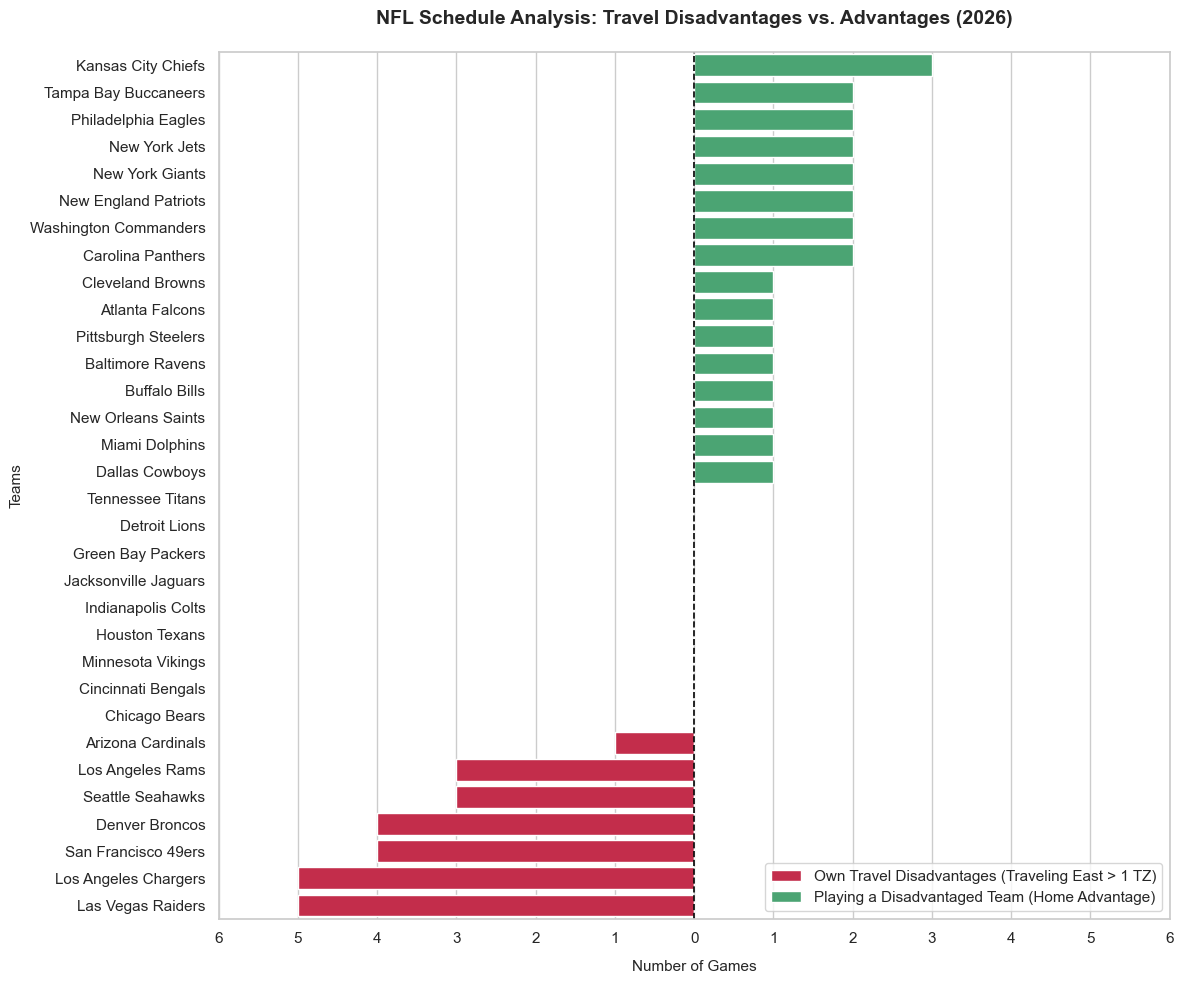

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Load your hand-marked dataset
df = pd.read_csv('data/2026_schedule.csv')


# Clean up column names and safely evaluate the manual input
df = df.rename(columns={'Unnamed: 2': 'Date', 'Unnamed: 5': 'LocationIndicator'})
df['is_international_bool'] = df['Is_International'].astype(str).str.upper().str.strip().isin(['TRUE', '1', 'YES'])

# 2. Define the team-to-timezone map
tz_map = {
    'New England Patriots': -5, 'New York Jets': -5, 'Buffalo Bills': -5, 'Miami Dolphins': -5,
    'Baltimore Ravens': -5, 'Cincinnati Bengals': -5, 'Cleveland Browns': -5, 'Pittsburgh Steelers': -5,
    'Indianapolis Colts': -5, 'Jacksonville Jaguars': -5, 'New York Giants': -5, 'Philadelphia Eagles': -5,
    'Washington Commanders': -5, 'Detroit Lions': -5, 'Atlanta Falcons': -5, 'Carolina Panthers': -5,
    'Tampa Bay Buccaneers': -5,
    'Houston Texans': -6, 'Tennessee Titans': -6, 'Kansas City Chiefs': -6, 'Dallas Cowboys': -6,
    'Chicago Bears': -6, 'Green Bay Packers': -6, 'Minnesota Vikings': -6, 'New Orleans Saints': -6,
    'Denver Broncos': -7, 'Arizona Cardinals': -7,
    'Las Vegas Raiders': -8, 'Los Angeles Chargers': -8, 'Los Angeles Rams': -8, 'San Francisco 49ers': -8,
    'Seattle Seahawks': -8
}

df['VisTm_TZ'] = df['VisTm'].map(tz_map)
df['HomeTm_TZ'] = df['HomeTm'].map(tz_map)
df['Vis_Travel_East'] = df['HomeTm_TZ'] - df['VisTm_TZ']

# Flag games with travel disadvantage (Traveling East > 1 timezone, and not international)
df['Has_Travel_Disadvantage'] = (df['Vis_Travel_East'] > 1) & (~df['is_international_bool'])

# 3. Aggregate metrics per team
own_disadvantage = df[df['Has_Travel_Disadvantage']].groupby('VisTm').size()
playing_disadvantaged = df[df['Has_Travel_Disadvantage']].groupby('HomeTm').size()

all_teams = sorted(list(tz_map.keys()))
summary_df = pd.DataFrame(index=all_teams)
summary_df['Own_Travel_Disadvantages'] = summary_df.index.map(own_disadvantage).fillna(0).astype(int)
summary_df['Playing_Disadvantaged_Teams'] = summary_df.index.map(playing_disadvantaged).fillna(0).astype(int)

# Calculate Net Disadvantage: Own - Playing
summary_df['Net_Disadvantage'] = summary_df['Own_Travel_Disadvantages'] - summary_df['Playing_Disadvantaged_Teams']

# Sort dataframe so the worst net disadvantage (highest value) is at the top of the horizontal plot
summary_df = summary_df.sort_values(by='Net_Disadvantage', ascending=True)

# Make 'Own' values negative so they extend leftward from 0 on the x-axis
summary_df['Neg_Own_Travel_Disadvantages'] = -summary_df['Own_Travel_Disadvantages']

# 4. Generate the Chart with Seaborn Theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 10))

# Plot the left-extending bars (Disadvantages)
sns.barplot(
    x='Neg_Own_Travel_Disadvantages', 
    y=summary_df.index, 
    data=summary_df, 
    color='crimson', 
    label='Own Travel Disadvantages (Traveling East > 1 TZ)', 
    ax=ax
)

# Plot the right-extending bars (Advantages)
sns.barplot(
    x='Playing_Disadvantaged_Teams', 
    y=summary_df.index, 
    data=summary_df, 
    color='mediumseagreen', 
    label='Playing a Disadvantaged Team (Home Advantage)', 
    ax=ax
)

# Add a strong center baseline at x=0
ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--')

# Adjust the X-axis labels to display absolute values (removing negative signs)
max_val = max(summary_df['Own_Travel_Disadvantages'].max(), summary_df['Playing_Disadvantaged_Teams'].max())
ticks = np.arange(-max_val - 1, max_val + 2)
ax.set_xticks(ticks)
ax.set_xticklabels([str(abs(t)) for t in ticks])

# Customizing axes and titles
ax.set_xlabel('Number of Games', fontsize=11, labelpad=10)
ax.set_ylabel('Teams', fontsize=11)
ax.set_title('NFL Schedule Analysis: Travel Disadvantages vs. Advantages (2026)', fontsize=14, weight='bold', pad=20)
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()

# Save the finalized visualization
plt.savefig('schedule_advantages_disadvantages_seaborn.png', dpi=300)

In [15]:
summary_df.to_csv("2026_travel_screwage.csv")